# Attention

По сути, что такое внимание?

Пожалуй, самый важный механизм в трансформенной архитектуре — это внимание. Он позволяет нейросети понять, какая часть входной последовательности наиболее релевантна задаче. Механизм внимания определяет для каждого токена последовательности, какие другие токены необходимы для его понимания в данном контексте. Прежде чем мы перейдем тому, как это реализовано в трансформере, давайте сначала разберемся, чего пытается добиться механизм внимания.

Этот механизм можно представить как метод, который заменяет каждый эмбеддинг токена на эмбеддинг, содержащий информацию о соседних токенах, вместо использования одинакового эмбеддинга для каждого токена вне зависимости от контекста. Если бы мы знали, какие токены релевантны текущему, то узнать его контекст можно с помощью средневзвешенного — или, в общем случае, линейной комбинации — этих эмбеддингов.

<img src = 'https://habrastorage.org/getpro/habr/upload_files/e45/a14/6d1/e45a146d14805fdc5c7b888e951416b8.png'>

Давайте посмотрим, как это может выглядеть для одного из наших предложений. До применениея механизма внимания у эмбеддингов в последовательности нет контекста их соседей. Поэтому мы можем визуализировать эмбеддинг для слова light как линейную комбинацию:

<img src= "https://habrastorage.org/getpro/habr/upload_files/560/963/6db/5609636dbb10bca8a596e955421d372f.png">

Здесь наши веса — это матрица тождественностей. А применив механизм внимания, мы хотим узнать матрицу весов, которая позволит нам подобным образом выразить эмбеддинг для слова light:

<img src = 'https://habrastorage.org/getpro/habr/upload_files/6b7/c99/6d0/6b7c996d09ad6a44c307a999eefecf1b.png'>

В этот раз эмбеддингам, соответствующим наиболее релевантным для выбранного токена частям последовательности, присвоены веса большего размера. Это должно обеспечить размещение в новом векторе эмбеддинга самого важного контекста. Эмбеддинги, содержащие информацию об их текущем контексте, иногда называют контекстуализированными, и именно такие мы хотим создать.
Мы поверхностно рассмотрели, что пытается добиться механизм внимания. Давайте теперь разберемся, как именно это реализовано.

Зададим понятие сходства между двумя эмбеддингами. Один из способов его представления — скалярное произведение. То есть мы хотим выучить такие эмбеддинги, при которых чем больше произведение, тем больше сходство двух слов:

<img src='https://habrastorage.org/getpro/habr/upload_files/990/524/342/9905243423653b5b5027da2b1c7a5af7.png'>

# SelfAttention

Немного математики: https://qudata.com/ml/ru/NN_Attention.html


Self-attention — это обучаемая матрица смешивания токенов. Матрицы $W_q, W_k$ определяют, кто с кем будет взаимодействовать. Матрица $W_v$ определяет, что именно передастся при взаимодействии.

$W_q$ формирует пространство запросов. Изменяя $W_q$, модель учится понимать:
- какие признаки важны при поиске
- как токен должен «смотреть» на других

$W_k$ формирует пространство ключей. Изменяя $W_k$ , модель учится понимать:
- какие признаки делают токен релевантным
- как токен должен быть «видимым»

$W_v$ формирует пространство передачи информации. Изменяя $W_v$, модель учится понимать:
- какие признаки реально нужны дальше
- что следует агрегировать

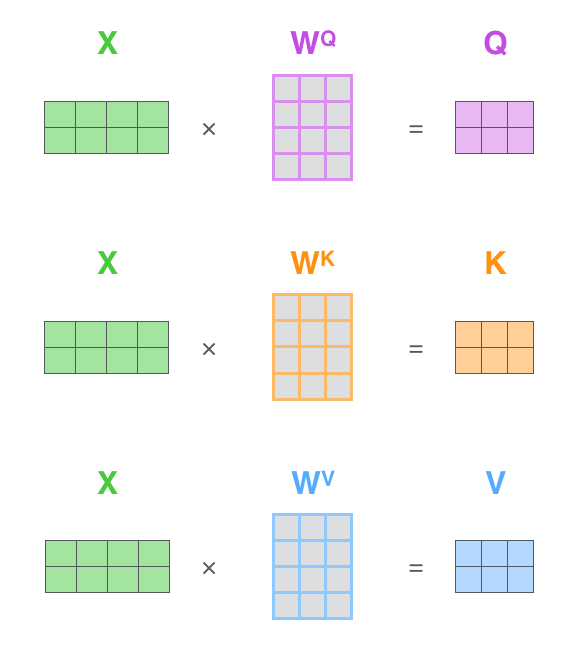

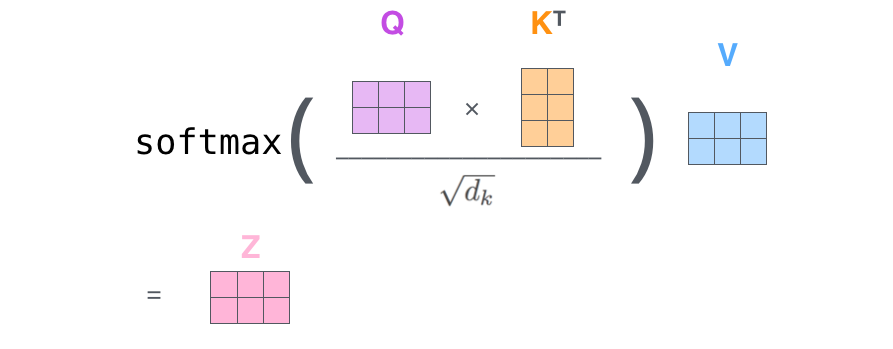

Пусть вход — матрица токенов $X \in R^{n \times d_k}$, где $n$ — длина последовательности, $d_k$ — размерность пространств $Q$ и $K$.

В модели формируются пары ключ-значение $(k ,v)$, к ним пременяется запрос $q$.

Self-attention определяется как
$$
Attn(X) = softmax \biggl(\frac{X \, W_Q \,(X \, W_K)^T}{\sqrt{d_k}} \biggr)\, X \, W_V
$$

Обозначим $Q = X \, W_Q , K = X W_K, V =X W_V$

Тогда
$$
Attn(X)= AV,
$$
где
$$
A=softmax \biggl(\frac{Q K^T}{\sqrt{d_k}} \biggr)
$$


Self-attention — это обучаемая матрица смешивания токенов. Преобразование Softmax добавляется, чтобы получить среднее взвешенное запроса.  Матрицы $W_q, W_k$ определяют, кто с кем будет взаимодействовать. Матрица $W_v$ определяет, что именно передастся при взаимодействии.

$W_q$ формирует пространство запросов. Изменяя $W_q$, модель учится понимать:
- какие признаки важны при поиске
- как токен должен «смотреть» на других

$W_k$ формирует пространство ключей. Изменяя $W_k$ , модель учится понимать:
- какие признаки делают токен релевантным
- как токен должен быть «видимым»

$W_v$ формирует пространство передачи информации. Изменяя $W_v$, модель учится понимать:
- какие признаки реально нужны дальше
- что следует агрегировать

Нормировка на корень из размерности позволяет сделать SoftMax более сглаженным. Беда может заключаться в том, что в результате скалярного произведения могут образовываться слишком большие или слишком маленькие значения, соответственно, будет слишком большой разброс, и когда мы будем считать экспоненту, получим вектор, который стремится к нулям или к единицам.

Чтобы этого не происходило, производится деление на корень из размерности. Идея в том, что скалярное произведение двух векторов в пространстве размерности  $d$  — это сумма  $d$ компонент. Закон больших чисел говорит о том, что когда мы складываем много одинаково распределенных случайных величин, то их дисперсия растет пропорционально $d$ и, соответственно, среднеквадратическое отклонение — это  $\sqrt{d}$.

1. Матрица $Q$ запросов (query) $Q=XW_q$ - линейная проекция, которая указывает на то, какие признаки токена участвуют в сравнении.

2. Матрица $K$ ключей (key) $K=XW_k$ - линейная проекция, которая указывает на то, какие признаки токена используются, чтобы его находили.

3. Матрица $V$ значений (value) $V=XW_v$ - линейная проекция, которая указывает на то, какие признаки передаются дальше.

Вся формула через них

$$Attn(X)=softmax\biggl(\frac{X \, W_q \, {W_k}^T \, X^T}{\sqrt{d_k}}\biggr) \,X \, W_v$$


Заметим:
$M=W_q {W_k}^T$


Тогда сходство:
$x_i^T M x_j$

То есть $W_q$ и $W_k$ задают обучаемую билинейную форму.

Это динамическое построение контекста. Каждый токен
- Формирует запрос $Q$ — это "что мне нужно"
- Смотрит на все $K$ - это "что у других есть"
- Выбирает важные
- Забирает их $V$ — это "что они реально передают"


Создание трёх матриц $Q, K, V$ - это просто три разных способа посмотреть на один и тот же embedding.

Слово банк (bank) отражает следующие сущности:
- как Query: «мне нужен объект, связанный с деньгами»
- как Key: «я финансовый термин»
- как Value: «я передаю финансовую информацию»


## Пример механизма внимания.

Инициализация

In [1]:
import numpy as np
from  scipy.special import softmax

np.set_printoptions(suppress=True)
np.set_printoptions(precision=5)

def mini_transformer(Input, Wq, Wk, Wv):
    Q = np.matmul(Input,Wq)
    K = np.matmul(Input,Wk)
    V = np.matmul(Input,Wv)

    QKtr = np.matmul(Q,K.transpose())
    smaxQKtr = softmax(QKtr,axis=1)

    A = np.matmul(smaxQKtr, V)

    input_with_attention = Input + A

    print("Input:\n{}".format(Input))

    print("Wq:\n{}".format(Wq))
    print("Wk:\n{}".format(Wk))
    print("Wv:\n{}".format(Wv))

    print("Q:\n{}".format(Q))
    print("K:\n{}".format(K))
    print("V:\n{}".format(V))

    print("QKtr:\n{}".format(QKtr))
    print("smaxQKtr:\n{}".format(smaxQKtr))
    print("A:\n{}".format(A))

    print("Output = Input + A:\n{}".format(input_with_attention))

## Задача 1. "Все со всеми"

In [2]:
Input = np.array([
              [0.8, 0,   0,     0],   # Я
              [0,   0.7, 0,     0],   # хочу
              [0,   0,   0.6,   0],   # на
              [0,   0,   0,   0.5], # улицу
            ])

Wq = np.array([
              [1,0,0,0],
              [0,1,0,0],
              [0,0,1,0],
              [0,0,0,1],
            ])

Wk = np.array([
              [1,0,0,0],
              [0,1,0,0],
              [0,0,1,0],
              [0,0,0,1],
            ])

Wv = np.array([
              [1,0,0,0],
              [0,1,0,0],
              [0,0,1,0],
              [0,0,0,1],
            ])

mini_transformer(Input, Wq, Wk, Wv)

Input:
[[0.8 0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.6 0. ]
 [0.  0.  0.  0.5]]
Wq:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
Wk:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
Wv:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
Q:
[[0.8 0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.6 0. ]
 [0.  0.  0.  0.5]]
K:
[[0.8 0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.6 0. ]
 [0.  0.  0.  0.5]]
V:
[[0.8 0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.6 0. ]
 [0.  0.  0.  0.5]]
QKtr:
[[0.64 0.   0.   0.  ]
 [0.   0.49 0.   0.  ]
 [0.   0.   0.36 0.  ]
 [0.   0.   0.   0.25]]
smaxQKtr:
[[0.38732 0.20423 0.20423 0.20423]
 [0.21587 0.35238 0.21587 0.21587]
 [0.22556 0.22556 0.32331 0.22556]
 [0.23343 0.23343 0.23343 0.29972]]
A:
[[0.30985 0.14296 0.12254 0.10211]
 [0.1727  0.24666 0.12952 0.10794]
 [0.18045 0.15789 0.19398 0.11278]
 [0.18674 0.1634  0.14006 0.14986]]
Output = Input + A:
[[1.10985 0.14296 0.12254 0.10211]
 [0.1727  0.94666 0.12952 0.10794]
 [0.18045 0.15789 0.79398 0.11278]
 [0.18674 

## Задача 2. Обратить внимание на слово "хочу"

In [3]:
Input = np.array([
              [0.8, 0,  0,  0],   # Я
              [0,   0.7,0,  0],   # хочу
              [0,   0,  0.6,0],   # на
              [0,   0,  0,  0.5], # улицу
            ])

Wq = np.array([
              [1,0,0,0],
              [0,1,0,0],
              [0,0,1,0],
              [0,0,0,1],
            ])

Wk = np.array([
              [0,0,0,0],
              [0,1,0,0],
              [0,0,0,0],
              [0,0,0,0],
            ])

Wv = np.array([
              [0, 0,   0, 0],
              [0, 0.2, 0, 0],
              [0, 0,   0, 0],
              [0, 0,   0, 0],
            ])

mini_transformer(Input, Wq, Wk, Wv)

Input:
[[0.8 0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.6 0. ]
 [0.  0.  0.  0.5]]
Wq:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
Wk:
[[0 0 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Wv:
[[0.  0.  0.  0. ]
 [0.  0.2 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]
Q:
[[0.8 0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.6 0. ]
 [0.  0.  0.  0.5]]
K:
[[0.  0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]
V:
[[0.   0.   0.   0.  ]
 [0.   0.14 0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.   0.   0.   0.  ]]
QKtr:
[[0.   0.   0.   0.  ]
 [0.   0.49 0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.   0.   0.   0.  ]]
smaxQKtr:
[[0.25    0.25    0.25    0.25   ]
 [0.21587 0.35238 0.21587 0.21587]
 [0.25    0.25    0.25    0.25   ]
 [0.25    0.25    0.25    0.25   ]]
A:
[[0.      0.035   0.      0.     ]
 [0.      0.04933 0.      0.     ]
 [0.      0.035   0.      0.     ]
 [0.      0.035   0.      0.     ]]
Output = Input + A:
[[0.8     0.035   0.      0.     ]
 [0.      0.74933 0.      0.    

## Задача 3. "Убрать из исходной последовательности слово хочу"

In [6]:
Input = np.array([
              [0.8, 0,  0,  0],   # Я
              [0,   0.7,0,  0],   # хочу
              [0,   0,  0.6,0],   # на
              [0,   0,  0,  0.5], # улицу
            ])

Wq = np.array([
              [1,0,0,0],
              [0,1,0,0],
              [0,0,1,0],
              [0,0,0,1],
            ])

Wk = np.array([
              [0,0,0,0],
              [0,1,0,0],
              [0,0,0,0],
              [0,0,0,0],
            ])

Wv = np.array([
              [0,0,0,0],
              [0,0.2,0,0],
              [0,0,0,0],
              [0,0,0,0],
            ])

mini_transformer(Input, Wq, Wk, Wv)

Input:
[[0.8 0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.6 0. ]
 [0.  0.  0.  0.5]]
Wq:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
Wk:
[[0 0 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Wv:
[[0.  0.  0.  0. ]
 [0.  0.2 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]
Q:
[[0.8 0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.6 0. ]
 [0.  0.  0.  0.5]]
K:
[[0.  0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]
V:
[[0.   0.   0.   0.  ]
 [0.   0.14 0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.   0.   0.   0.  ]]
QKtr:
[[0.   0.   0.   0.  ]
 [0.   0.49 0.   0.  ]
 [0.   0.   0.   0.  ]
 [0.   0.   0.   0.  ]]
smaxQKtr:
[[0.25    0.25    0.25    0.25   ]
 [0.21587 0.35238 0.21587 0.21587]
 [0.25    0.25    0.25    0.25   ]
 [0.25    0.25    0.25    0.25   ]]
A:
[[0.      0.035   0.      0.     ]
 [0.      0.04933 0.      0.     ]
 [0.      0.035   0.      0.     ]
 [0.      0.035   0.      0.     ]]
Output = Input + A:
[[0.8     0.035   0.      0.     ]
 [0.      0.74933 0.      0.    

## Задача 4. Забыть слово "Я"

In [7]:
Input = np.array([
              [0.8, 0,  0,  0],   # Я
              [0,   0.7,0,  0],   # хочу
              [0,   0,  0.6,0],   # на
              [0,   0,  0,  0.5], # улицу
            ])

Wq = np.array([
              [1,0,0,0],
              [0,0,0,0],
              [0,0,0,0],
              [0,0,0,0],
            ])

Wk = np.array([
              [10,0,0,0],
              [0,0,0,0],
              [0,0,0,0],
              [0,0,0,0],
            ])

Wv = np.array([
              [-1,0,0,0],
              [0,0,0,0],
              [0,0,0,0],
              [0,0,0,0],
            ])

mini_transformer(Input, Wq, Wk, Wv)

Input:
[[0.8 0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.6 0. ]
 [0.  0.  0.  0.5]]
Wq:
[[1 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Wk:
[[10  0  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]]
Wv:
[[-1  0  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]]
Q:
[[0.8 0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]
K:
[[8. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
V:
[[-0.8  0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]
 [ 0.   0.   0.   0. ]]
QKtr:
[[6.4 0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]
smaxQKtr:
[[0.99504 0.00165 0.00165 0.00165]
 [0.25    0.25    0.25    0.25   ]
 [0.25    0.25    0.25    0.25   ]
 [0.25    0.25    0.25    0.25   ]]
A:
[[-0.79603  0.       0.       0.     ]
 [-0.2      0.       0.       0.     ]
 [-0.2      0.       0.       0.     ]
 [-0.2      0.       0.       0.     ]]
Output = Input + A:
[[ 0.00397  0.       0.       0.     ]
 [-0.2      0.7      0.       0.     ]
 [-0.

<img src = 'https://media.licdn.com/dms/image/v2/D4E22AQEZeFvfqBpY0Q/feedshare-shrink_800/feedshare-shrink_800/0/1718211035911?e=2147483647&v=beta&t=QdWXAZr1beTkz4XGKM2ixewly4iGsH-KBjzDDMOeh4Y'>